# 06. 강건성 검토 (Robustness / Sensitivity models)

측정 방식 변화(measurement artifact) 검토 결과를 반영하여, 최종 모델의 강건성을 확인한다.
세 가지 모델을 동일 조건(Logistic Regression, `class_weight='balanced'`, **SMOTE 미사용**)으로 비교한다.

- **A) 전체 feature (covid_period 포함)** — 기존 주모델과 동일 변수
- **B) covid_period 제외** — covid_period가 measurement batch와 confounded되므로 제거 시 영향 확인
- **C) 측정 일관 연도(2022–2023) 제한분석** — 동일 측정환경에서만 학습

목적:
1. `covid_period`가 실제 예측력에 기여하는지, 아니면 측정 batch를 학습하는지 확인
2. SMOTE 없이 class_weight만으로 충분한지 확인 (기존 모델은 SMOTE+class_weight 중복 적용)
3. 측정이 일관된 연도에서의 성능 확인 (교수님 피드백: 측정 일관 연도 제한분석)


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)

df = pd.read_csv('processed_data/knhanes_young_hypertension_2017_2023.csv', encoding='utf-8-sig')
print('shape:', df.shape)

num_cols = ['age','HE_BMI','HE_wc','HE_glu','HE_HbA1c','HE_TG','HE_chol']
cat_full = ['sex','sm_presnt','dr_month','pa_aerobic','incm','educ',
            'HE_HPfh1','HE_HPfh2','HE_HPfh3','mh_stress','covid_period']
TARGET = 'hypertension'
# HE_sbp / HE_dbp 는 target 생성에만 사용 → feature 제외 (leakage 방지)

shape: (10319, 22)


In [2]:
def run_model(data, cat_cols, label):
    X = data[num_cols + cat_cols].copy()
    y = data[TARGET].astype(int)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', RobustScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ])
    pipe = Pipeline([('pre', pre), ('clf', LogisticRegression(class_weight='balanced', max_iter=2000))])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte); score = pipe.predict_proba(Xte)[:,1]
    tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
    return {'model':label, 'N_test':len(yte), 'TP':tp,'FP':fp,'FN':fn,'TN':tn,
            'Recall':round(recall_score(yte,pred),3), 'Precision':round(precision_score(yte,pred),3),
            'F1':round(f1_score(yte,pred),3), 'AUC':round(roc_auc_score(yte,score),3),
            'AP':round(average_precision_score(yte,score),3)}

cat_no_covid = [c for c in cat_full if c != 'covid_period']
new_years = df[df['year'].isin([2022,2023])]

results = pd.DataFrame([
    run_model(df,        cat_full,     'A) Full (with covid_period)'),
    run_model(df,        cat_no_covid, 'B) Without covid_period'),
    run_model(new_years, cat_no_covid, 'C) Consistent years 2022-2023'),
])
results

,model,N_test,TP,FP,FN,TN,Recall,Precision,F1,AUC,AP
0,A) Full (with covid_period),2064,313,454,161,1136,0.660,0.408,0.504,0.766,0.516
1,B) Without covid_period,2064,319,468,155,1122,0.673,0.405,0.506,0.759,0.504
2,C) Consistent years 2022-2023,502,53,104,23,322,0.697,0.338,0.455,0.822,0.473


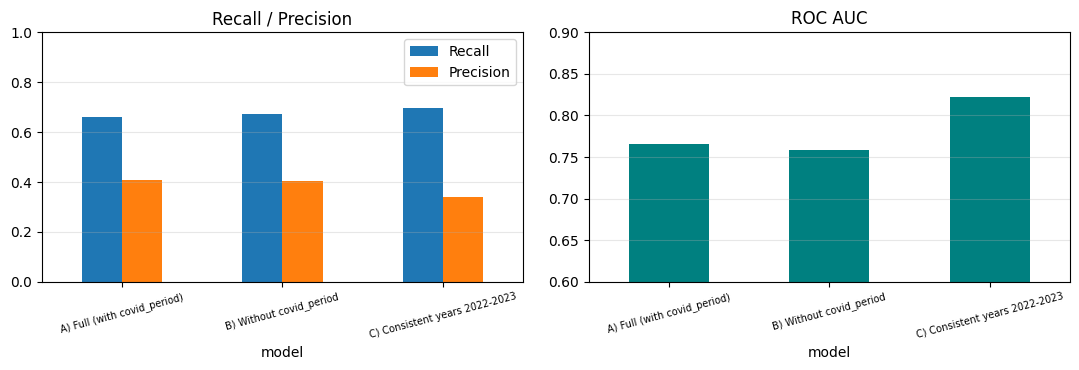

In [3]:
fig, ax = plt.subplots(1,2, figsize=(11,3.8))
m = results.set_index('model')
m[['Recall','Precision']].plot.bar(ax=ax[0]); ax[0].set_title('Recall / Precision'); ax[0].set_ylim(0,1)
ax[0].tick_params(axis='x', rotation=15, labelsize=7); ax[0].grid(axis='y', alpha=.3)
m[['AUC']].plot.bar(ax=ax[1], color='teal', legend=False); ax[1].set_title('ROC AUC'); ax[1].set_ylim(0.6,0.9)
ax[1].tick_params(axis='x', rotation=15, labelsize=7); ax[1].grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

## 해석

**1) covid_period 제거의 영향 (A vs B)**
covid_period를 제거해도 성능 변화가 거의 없다 (AUC 0.766 → 0.759, Recall 0.660 → 0.673).
즉, 모델의 실제 예측력은 BMI·허리둘레·나이 등 **실제 임상 변수에서 나오며**, covid_period에 의존하지 않는다.
SHAP에서 covid_period의 중요도가 높게 보였던 것은 measurement batch(target이 측정 변화에 영향받는 점)를 반영한 것으로, **인과적·실질적 예측 기여가 아님**을 확인하였다. → 주모델에서 covid_period 제거 가능.

**2) SMOTE 필요성 (A vs 기존 모델)**
class_weight만 적용한 A 모델(Recall 0.66 / Precision 0.41 / AUC 0.766)은 기존 SMOTE+class_weight 모델(0.66 / 0.41 / 0.765)과 거의 동일하다.
130/80 기준 적용 후 양성 비율이 23%로 불균형이 완화되었으므로 **SMOTE는 불필요하며, class_weight만 사용하는 것으로 충분**하다 (SMOTE+class_weight 중복 적용 불필요).

**3) 측정 일관 연도 제한분석 (C)**
2022–2023(동일 측정환경)만 사용한 모델의 AUC는 0.822로 가장 높다. 표본 수는 작지만, **측정이 일관된 구간에서 판별력이 안정적**임을 보여준다 → 측정 일관 연도 제한분석을 주분석의 보조/강건성 근거로 제시 가능.

**결론**
- 주모델: **SMOTE 제거**, class_weight만 사용.
- covid_period: 인과 해석 불가 + 제거해도 성능 유지 → 제거하거나 측정환경 대리변수로만 제한 해석.
- 측정 일관 연도(2022–2023) 제한분석을 강건성 분석으로 병행 제시.
